## Phase 1 : Dataset Exploration

### Step 1: Import Required Libraries

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

RANDOM_STATE = 42

### Step 2: Load Dataset

In [69]:
dataset_path = Path(
    "../datasets/crop_yield_prediction/crop_yield_prediction.csv"
)

print("Dataset Exists :", dataset_path.exists())

yield_df = pd.read_csv(dataset_path)

print("\nDataset Loaded Successfully")

print("Dataset Shape :", yield_df.shape)

Dataset Exists : True

Dataset Loaded Successfully
Dataset Shape : (19689, 10)


### Step 3: Dataset Overview

In [70]:
yield_df.head()


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [71]:
print("Dataset Shape :", yield_df.shape)


Dataset Shape : (19689, 10)


In [72]:
print(yield_df.columns.tolist())


['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']


In [73]:
yield_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  str    
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  str    
 3   State            19689 non-null  str    
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), str(3)
memory usage: 1.5 MB


### Step 4: Check Missing & Duplicate Values

In [74]:
print("Missing Values\n")

print(yield_df.isnull().sum())


Missing Values

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


In [75]:
print("\nDuplicate Records :", yield_df.duplicated().sum())


Duplicate Records : 0


### Step 5: Dataset Columns & Target

In [76]:
print("Dataset Columns:\n")

for column in yield_df.columns:
    print(column)

target_column = "Yield"

print("\nTarget Column :", target_column)

Dataset Columns:

Crop
Crop_Year
Season
State
Area
Production
Annual_Rainfall
Fertilizer
Pesticide
Yield

Target Column : Yield


### Step 6: Statistical Summary

In [77]:
yield_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Crop_Year,19689.0,2.009128e+03,6.498099e+00,1997.00,2004.00,2010.00,2.015000e+03,2.020000e+03
Area,19689.0,1.799266e+05,7.328287e+05,0.50,1390.00,9317.00,7.511200e+04,5.080810e+07
Production,19689.0,1.643594e+07,2.630568e+08,0.00,1393.00,13804.00,1.227180e+05,6.326000e+09
Annual_Rainfall,19689.0,1.437755e+03,8.169096e+02,301.30,940.70,1247.60,1.643700e+03,6.552700e+03
Fertilizer,19689.0,2.410331e+07,9.494600e+07,54.17,188014.62,1234957.44,1.000385e+07,4.835407e+09
Pesticide,19689.0,4.884835e+04,2.132874e+05,0.09,356.70,2421.90,2.004170e+04,1.575051e+07
Yield,19689.0,7.995401e+01,8.783062e+02,0.00,0.60,1.03,2.388889e+00,2.110500e+04


### Step 7: Exploratory Data Analysis

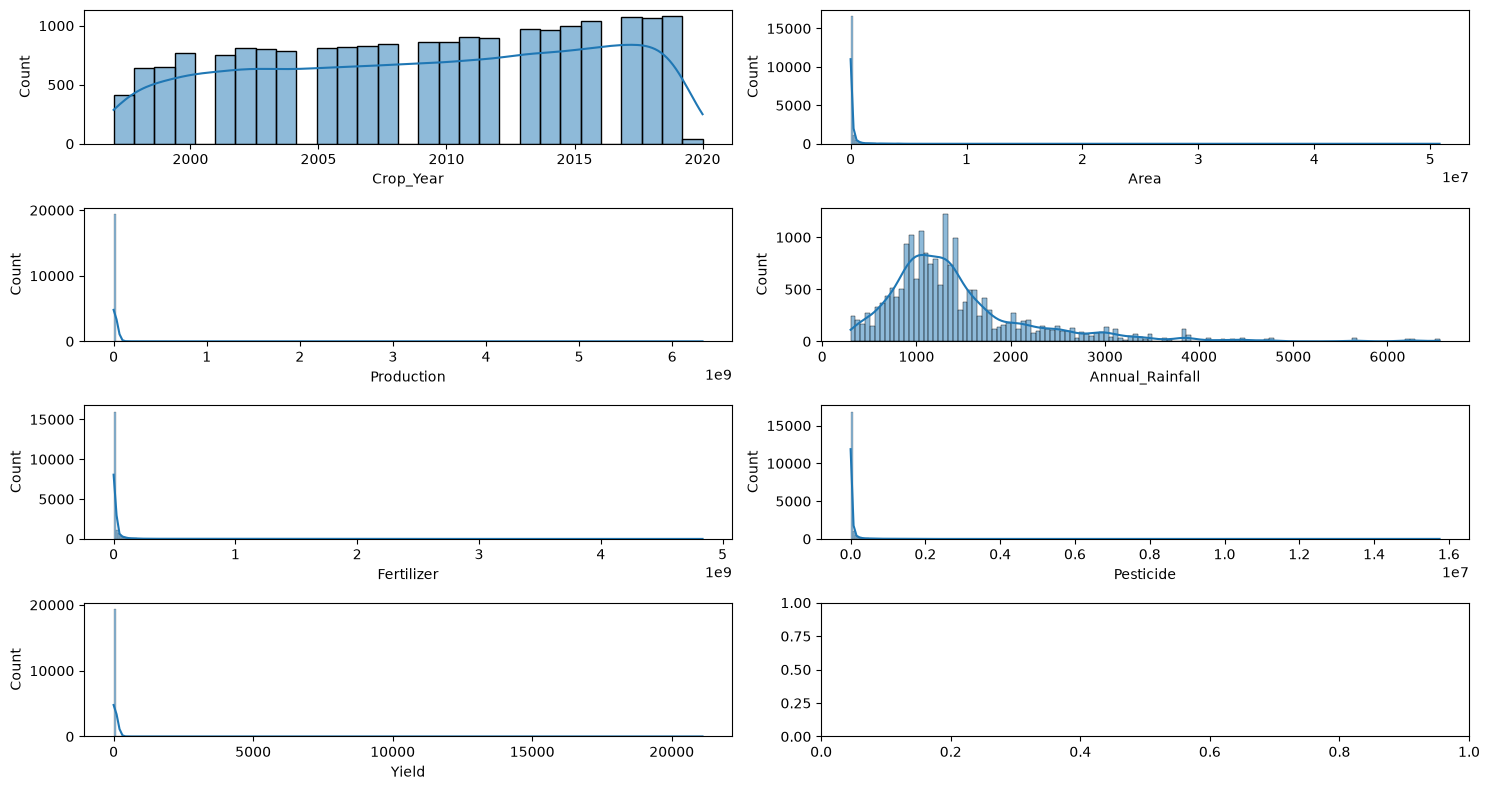

In [78]:
num_features= ["Crop_Year","Area","Production",
                "Annual_Rainfall","Fertilizer","Pesticide",
                "Yield"]
fig,axes=plt.subplots(4,2,figsize=(15,8))
axes=axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(yield_df[col],kde=True,ax=axes[i])
    #axes[i].set_title(col)
plt.tight_layout()
plt.show()


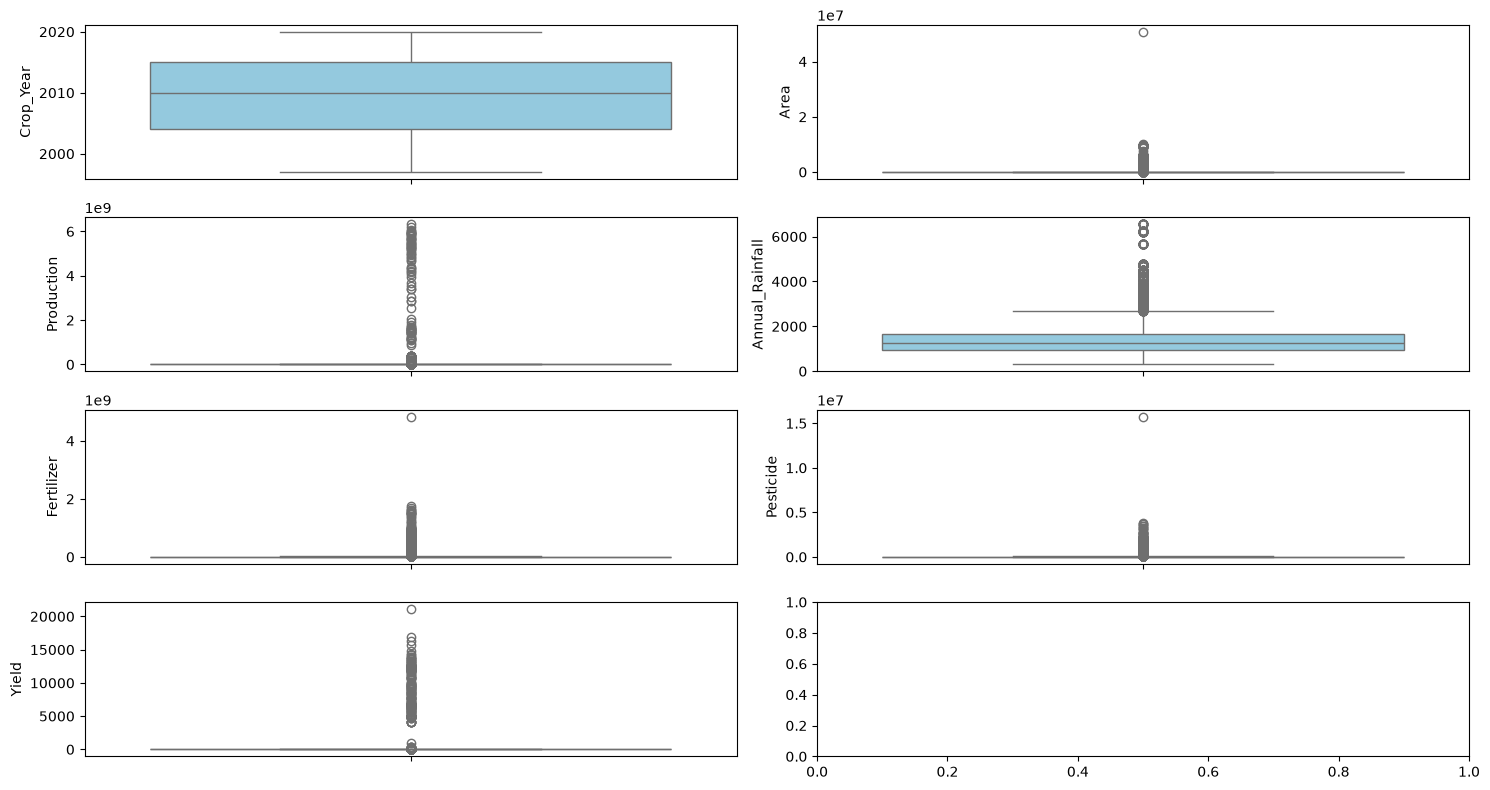

In [79]:
fig,axes=plt.subplots(4,2,figsize=(15,8))
axes=axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(y=yield_df[col], ax=axes[i],color="skyblue")
plt.tight_layout()
plt.show()

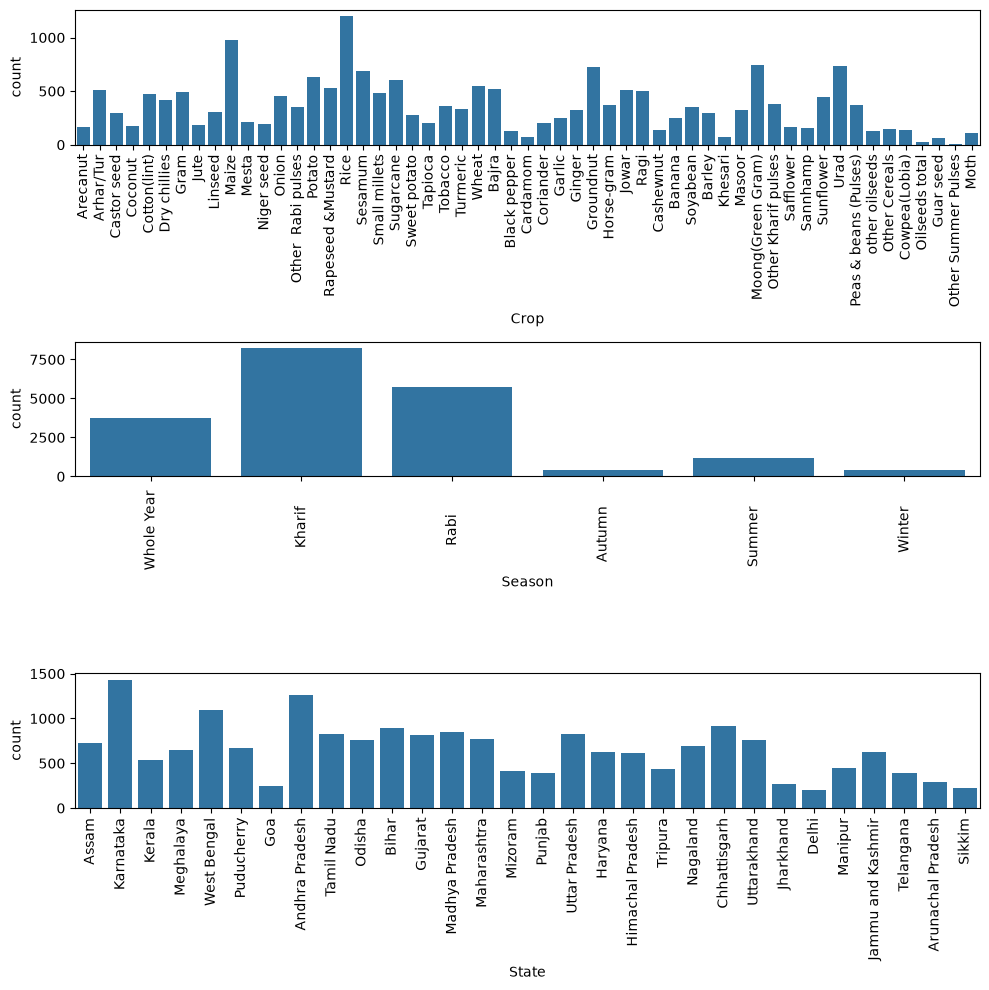

In [80]:
cat_features =["Crop","Season","State"]
fig,axes=plt.subplots(3,1,figsize=(10,10))
axes=axes.flatten()
for i, col in enumerate(cat_features):
    sns.countplot(data=yield_df,x=col,ax=axes[i])
    axes[i].tick_params(axis='x',rotation=90)
plt.tight_layout()
plt.show()


## Phase 2: Data Preparation

### Step 8: Feature Engineering

In [81]:
yield_df["Fertilizer_per_Area"] = (
    yield_df["Fertilizer"] /
    yield_df["Area"]
)

yield_df["Pesticide_per_Area"] = (
    yield_df["Pesticide"] /
    yield_df["Area"]
)

yield_df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Fertilizer_per_Area,Pesticide_per_Area
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087,95.17,0.31
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435,95.17,0.31
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333,95.17,0.31
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739,95.17,0.31
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909,95.17,0.31


### Step 9: Separate Features & Target

In [82]:
yield_df["Crop"] = yield_df["Crop"].str.strip()

yield_df["Season"] = yield_df["Season"].str.strip()

yield_df["State"] = yield_df["State"].str.strip()

In [83]:
X = yield_df.drop(columns="Yield")

y = yield_df["Yield"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (19689, 11)
Target Shape  : (19689,)


### Step 10: OneHotEncoder

In [84]:
cat_features = [
    "Crop",
    "Season",
    "State"
]

In [85]:
num_features = X.drop(columns=cat_features).columns

In [86]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)

X_cat = encoder.fit_transform(X[cat_features])

In [87]:
X_cat = pd.DataFrame(
    X_cat,
    columns=encoder.get_feature_names_out(cat_features),
    index=X.index
)

In [88]:
X = pd.concat(
    [
        X[num_features],
        X_cat
    ],
    axis=1
)

print("Encoded Feature Shape :", X.shape)

Encoded Feature Shape : (19689, 96)


### Step 11: Train-Test Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=RANDOM_STATE

)

print("Training Samples :", X_train.shape[0])

print("Testing Samples  :", X_test.shape[0])

print("\nTraining Feature Shape :", X_train.shape)

print("Testing Feature Shape  :", X_test.shape)

Training Samples : 15751
Testing Samples  : 3938

Training Feature Shape : (15751, 96)
Testing Feature Shape  : (3938, 96)


In [90]:
print("Final Feature Count :", X.shape[1])

print("\nFirst 10 Features:")

print(X.columns[:10].tolist())


Final Feature Count : 96

First 10 Features:
['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Fertilizer_per_Area', 'Pesticide_per_Area', 'Crop_Arhar/Tur', 'Crop_Bajra']


### Step 12: Feature Scaling

In [91]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

print("\nScaled Training Shape :", X_train_scaled.shape)

print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Completed Successfully

Scaled Training Shape : (15751, 96)
Scaled Testing Shape  : (3938, 96)


## Phase 3: Model Selection & Development

### Step 13: Train Baseline Regression Models

In [92]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )

}

results = []

print("Training Models...\n")

for name, model in models.items():

    
    if name == "Linear Regression":

        model.fit(X_train_scaled, y_train)

        predictions = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    results.append([name, r2, mae, rmse])

    print(f"{name:<20} R² : {r2:.4f}")

Training Models...

Linear Regression    R² : 0.8023
Decision Tree        R² : 0.9765
Random Forest        R² : 0.9865
Gradient Boosting    R² : 0.9878


### Step 14: Compare Model Performance

In [93]:
results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "R2 Score",
        "MAE",
        "RMSE"
    ]

)

results_df = results_df.sort_values(

    by="R2 Score",

    ascending=False

).reset_index(drop=True)

results_df

best_model_name = results_df.iloc[0]["Model"]

print(f"Best Performing Model : {best_model_name}")

Best Performing Model : Gradient Boosting


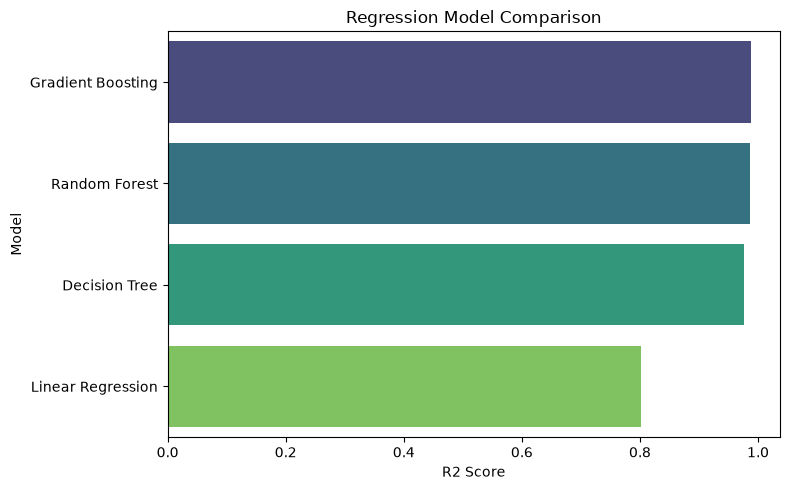

In [94]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=results_df,

    x="R2 Score",

    y="Model",

    hue="Model",

    palette="viridis",

    legend=False

)

plt.title("Regression Model Comparison")

plt.tight_layout()

plt.show()

### Step 15: Cross Validation

In [95]:
gb_model = GradientBoostingRegressor(
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:\n")
print(cv_scores)

print("\nAverage R² Score : {:.4f}".format(cv_scores.mean()))

Cross Validation R² Scores:

[0.96498842 0.95381335 0.99545634 0.77042505 0.98065826]

Average R² Score : 0.9331


### Step 16: Hyperparameter Tuning

In [96]:
param_grid = {

    "n_estimators": [100, 200],

    "learning_rate": [0.05, 0.1],

    "max_depth": [3, 5],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

grid_search = GridSearchCV(

    estimator=GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train, y_train)

print("\nHyperparameter Tuning Completed Successfully")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Hyperparameter Tuning Completed Successfully


In [97]:
print("Best Parameters:\n")

print(grid_search.best_params_)

print("\nBest Cross Validation R² Score :")

print(f"{grid_search.best_score_:.4f}")

Best Parameters:

{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation R² Score :
0.9557


### Step 17: Train Final Model

In [98]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

print("Final Optimized Gradient Boosting Model Trained Successfully")

Final Optimized Gradient Boosting Model Trained Successfully


## Phase 4 – Model Evaluation

### Step 18: Evaluate Final Model

In [99]:
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score : {r2:.4f}")

print(f"MAE      : {mae:.4f}")

print(f"RMSE     : {rmse:.4f}")

R² Score : 0.9870
MAE      : 8.1373
RMSE     : 102.0386


### Step 19: Residual Analysis

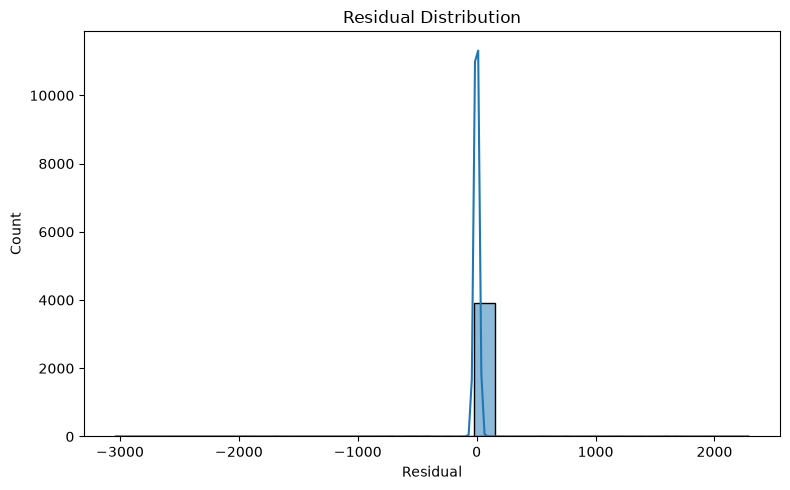

In [100]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True,
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.tight_layout()

plt.show()

### Step 20: Actual vs Predicted Plot

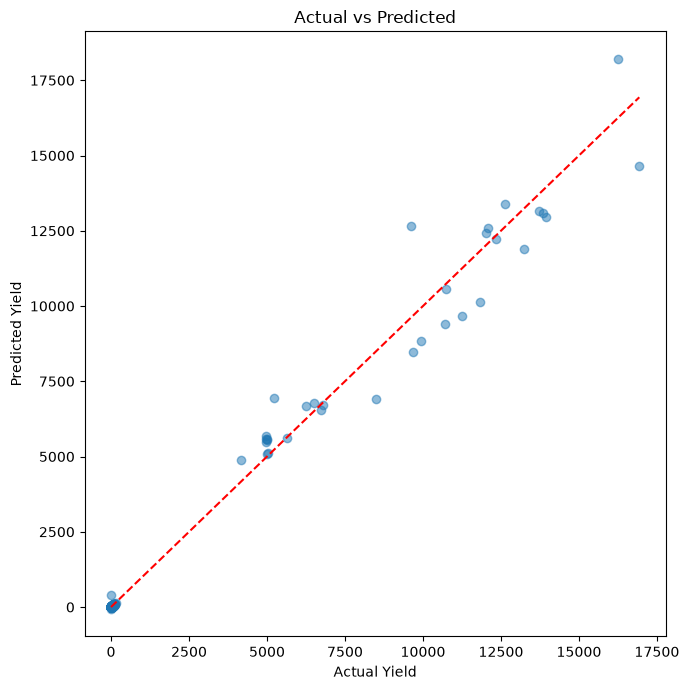

In [101]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Yield")

plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted")

plt.tight_layout()

plt.show()

### Step 21: Feature Importance

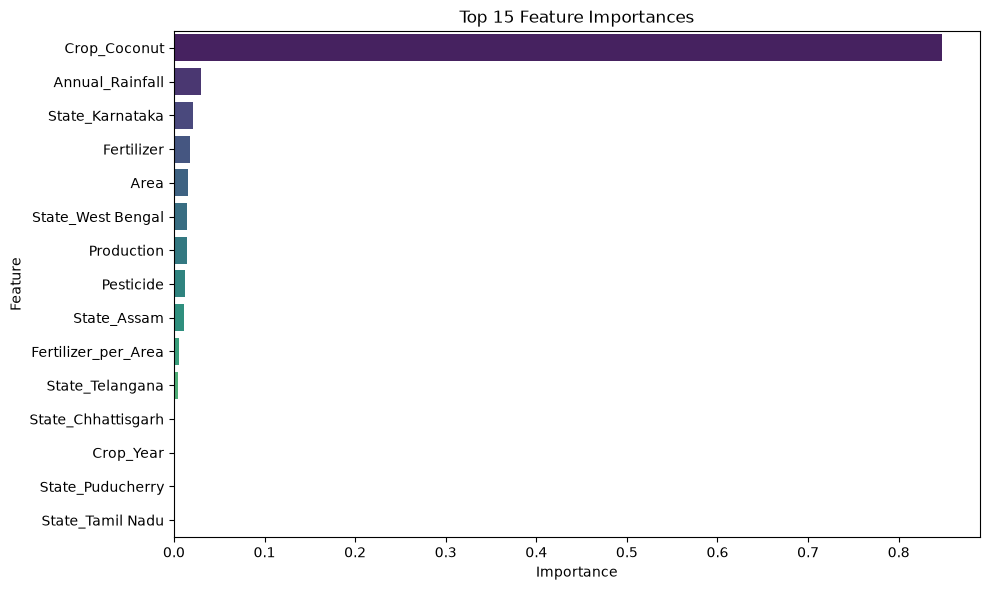

,Feature,Importance
16,Crop_Coconut,0.847386
3,Annual_Rainfall,0.030189
78,State_Karnataka,0.021492
4,Fertilizer,0.017651
1,Area,0.015670
95,State_West Bengal,0.014502
2,Production,0.014244
5,Pesticide,0.012566
68,State_Assam,0.010954
6,Fertilizer_per_Area,0.005087


In [102]:
feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

plt.figure(figsize=(10,6))

sns.barplot(

    data=feature_importance.head(15),

    x="Importance",

    y="Feature",

    hue="Feature",

    palette="viridis",

    legend=False

)

plt.title("Top 15 Feature Importances")

plt.tight_layout()

plt.show()

feature_importance.head(15)

## Phase 5: Model Saving

### Step 22: Save Model

In [103]:
model_directory = Path("../models")

model_directory.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    model_directory / "yield_prediction_model.pkl"
)

print("Yield Prediction Model Saved Successfully")

Yield Prediction Model Saved Successfully


### Step 23: Save Preprocessing Objects

In [104]:
joblib.dump(
    encoder,
    model_directory / "yield_encoder.pkl"
)

joblib.dump(
    scaler,
    model_directory / "yield_scaler.pkl"
)

joblib.dump(
    X.columns.tolist(),
    model_directory / "yield_feature_names.pkl"
)

print("Preprocessing Objects Saved Successfully")

Preprocessing Objects Saved Successfully


In [105]:
joblib.dump(
    cat_features,
    model_directory / "yield_categorical_columns.pkl"
)

print("Categorical Column Names Saved Successfully")

Categorical Column Names Saved Successfully


### Step 24: Prediction Function

In [106]:
def predict_crop_yield(input_data):
    """
    Predict crop yield using the trained Gradient Boosting model.

    Parameters:
        input_data (DataFrame): Preprocessed feature DataFrame
                                matching the training columns.

    Returns:
        float: Predicted crop yield.
    """

    prediction = best_model.predict(input_data)

    return prediction[0]

### Step 25: Test Prediction

In [107]:
print(encoder.get_feature_names_out(cat_features))

['Crop_Arhar/Tur' 'Crop_Bajra' 'Crop_Banana' 'Crop_Barley'
 'Crop_Black pepper' 'Crop_Cardamom' 'Crop_Cashewnut' 'Crop_Castor seed'
 'Crop_Coconut' 'Crop_Coriander' 'Crop_Cotton(lint)' 'Crop_Cowpea(Lobia)'
 'Crop_Dry chillies' 'Crop_Garlic' 'Crop_Ginger' 'Crop_Gram'
 'Crop_Groundnut' 'Crop_Guar seed' 'Crop_Horse-gram' 'Crop_Jowar'
 'Crop_Jute' 'Crop_Khesari' 'Crop_Linseed' 'Crop_Maize' 'Crop_Masoor'
 'Crop_Mesta' 'Crop_Moong(Green Gram)' 'Crop_Moth' 'Crop_Niger seed'
 'Crop_Oilseeds total' 'Crop_Onion' 'Crop_Other  Rabi pulses'
 'Crop_Other Cereals' 'Crop_Other Kharif pulses'
 'Crop_Other Summer Pulses' 'Crop_Peas & beans (Pulses)' 'Crop_Potato'
 'Crop_Ragi' 'Crop_Rapeseed &Mustard' 'Crop_Rice' 'Crop_Safflower'
 'Crop_Sannhamp' 'Crop_Sesamum' 'Crop_Small millets' 'Crop_Soyabean'
 'Crop_Sugarcane' 'Crop_Sunflower' 'Crop_Sweet potato' 'Crop_Tapioca'
 'Crop_Tobacco' 'Crop_Turmeric' 'Crop_Urad' 'Crop_Wheat'
 'Crop_other oilseeds' 'Season_Kharif' 'Season_Rabi' 'Season_Summer'
 'Season_Whole

In [ ]:
sample = pd.DataFrame(
    0,
    index=[0],
    columns=X.columns
)

sample["Crop_Year"] = 2024
sample["Area"] = 2.5
sample["Production"] = 8
sample["Annual_Rainfall"] = 1200
sample["Fertilizer"] = 150
sample["Pesticide"] = 20
sample["Fertilizer_per_Area"] = 150 / 2.5
sample["Pesticide_per_Area"] = 20 / 2.5

sample["Crop_Rice"] = 1
sample["Season_Kharif"] = 1
sample["State_Maharashtra"] = 1

predicted_yield = predict_crop_yield(sample)

print(f"Predicted Yield: {predicted_yield:.2f}")

Predicted Yield: 0.75
